# Phase E — Raw Nasdaq ITCH reconstruction

This notebook reads the saved Phase E outputs. It does not parse or reconstruct the raw session again.


In [11]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
output_dir = project_root / 'reports' / 'tables'
symbol = 'AAPL'

metrics_path = output_dir / f'phase_e_itch_{symbol}_reconstruction_metrics.json'
sample_path = output_dir / f'phase_e_itch_{symbol}_events_sample.csv'
counts_path = output_dir / f'phase_e_itch_{symbol}_message_counts.csv'

metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
sample = pd.read_csv(sample_path)
counts = pd.read_csv(counts_path)


## Reconstruction and throughput summary


In [7]:
summary = {
    'records_read': metrics['binary_file']['records_read'],
    'end_marker_seen': metrics['binary_file']['end_marker_seen'],
    'target_book_events': metrics['reconstruction']['target_book_events'],
    'max_open_orders': metrics['reconstruction']['max_open_orders'],
    'missing_target_order_references': metrics['reconstruction']['missing_target_order_references'],
    'share_underflows': metrics['reconstruction']['share_underflows'],
    'crossed_book_rows': metrics['reconstruction']['crossed_book_rows'],
    'locked_book_rows': metrics['reconstruction']['locked_book_rows'],
    'final_integrity_valid': metrics['final_integrity']['valid'],
    'records_per_second': metrics['benchmark']['records_per_second'],
    'target_events_per_second': metrics['benchmark']['target_book_events_per_second'],
    'peak_tracemalloc_mb': metrics['benchmark']['peak_tracemalloc_megabytes'],
}
pd.Series(summary, name='value').to_frame()


,value
records_read,368366634
end_marker_seen,False
target_book_events,1656597
max_open_orders,42774
missing_target_order_references,0
share_underflows,0
crossed_book_rows,0
locked_book_rows,0
final_integrity_valid,True
records_per_second,40469.979489


## Message-type counts


,message_type,count
0,A,162970455
3,D,158273361
14,U,27222746
4,E,8096995
16,X,4669874
7,I,3684511
5,F,1725898
10,P,1326184
9,L,193769
2,C,158886


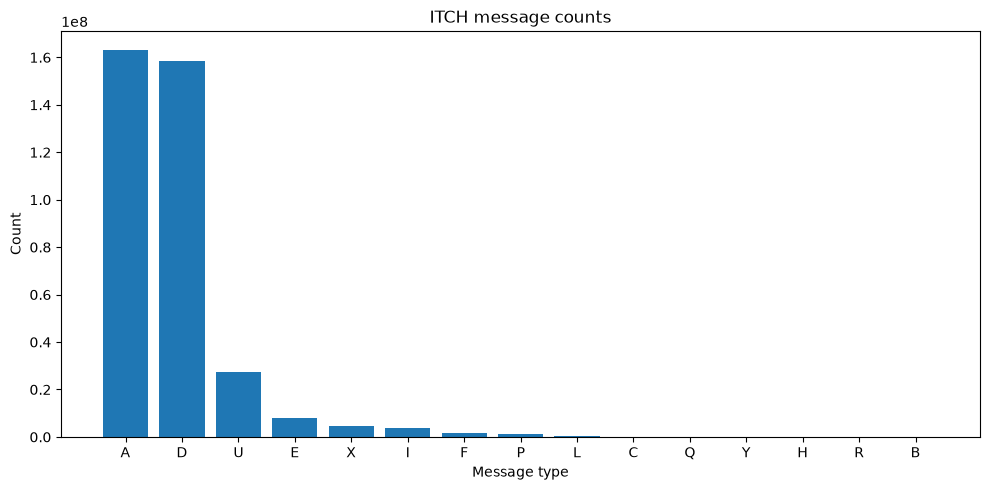

In [8]:
display(counts.sort_values('count', ascending=False).head(15))

figure, axis = plt.subplots(figsize=(10, 5))
ordered = counts.sort_values('count', ascending=False).head(15)
axis.bar(ordered['message_type'], ordered['count'])
axis.set_title('ITCH message counts')
axis.set_xlabel('Message type')
axis.set_ylabel('Count')
plt.tight_layout()
plt.show()


## Reconstructed top of book


,time_seconds,message_type,bid_price_1,ask_price_1,spread
0,34200.000245,D,163.24,163.34,0.1
1,34200.000256,D,163.24,163.34,0.1
2,34200.006086,F,163.24,163.34,0.1
3,34200.006105,F,163.24,163.34,0.1
4,34200.007270,X,163.24,163.34,0.1


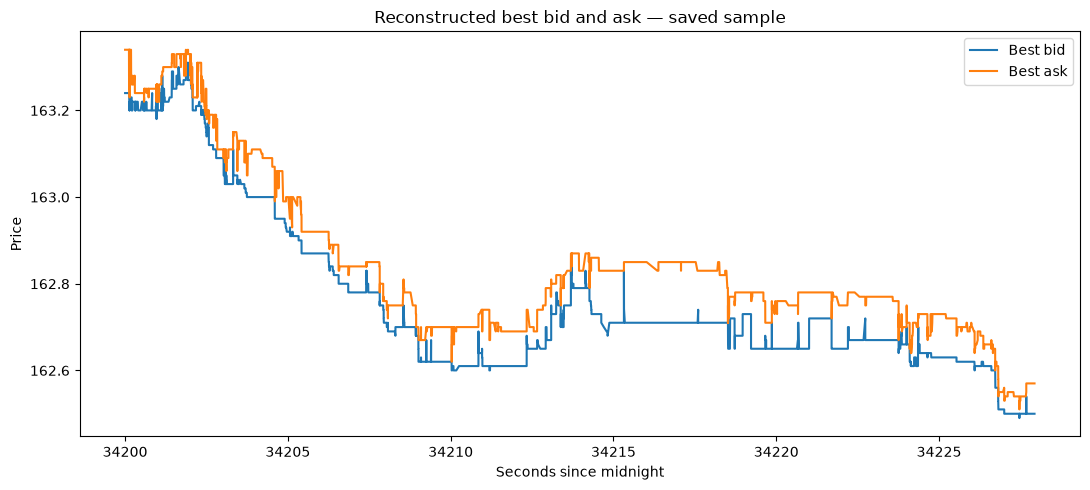

In [9]:
valid_quotes = sample.dropna(subset=['bid_price_1', 'ask_price_1']).copy()
valid_quotes['spread'] = valid_quotes['ask_price_1'] - valid_quotes['bid_price_1']
display(valid_quotes[['time_seconds', 'message_type', 'bid_price_1', 'ask_price_1', 'spread']].head())

figure, axis = plt.subplots(figsize=(11, 5))
axis.plot(valid_quotes['time_seconds'], valid_quotes['bid_price_1'], label='Best bid')
axis.plot(valid_quotes['time_seconds'], valid_quotes['ask_price_1'], label='Best ask')
axis.set_title('Reconstructed best bid and ask — saved sample')
axis.set_xlabel('Seconds since midnight')
axis.set_ylabel('Price')
axis.legend()
plt.tight_layout()
plt.show()


## Spread distribution


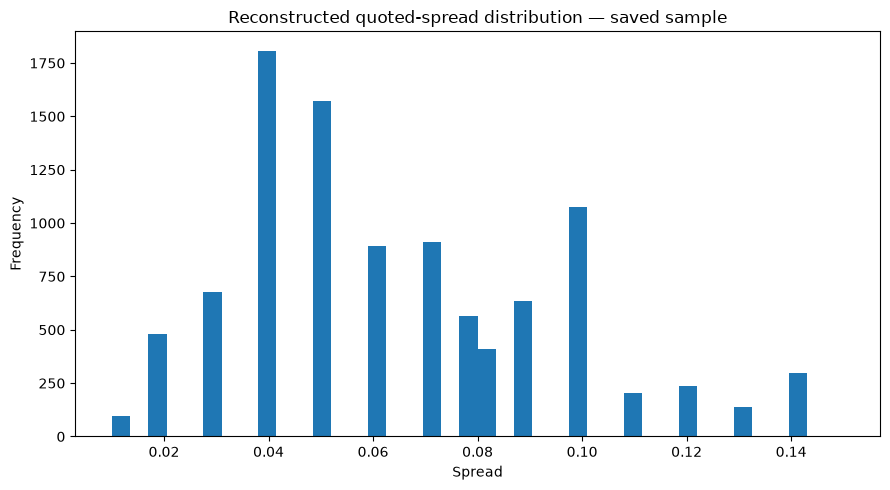

In [10]:
figure, axis = plt.subplots(figsize=(9, 5))
axis.hist(valid_quotes['spread'].dropna(), bins=40)
axis.set_title('Reconstructed quoted-spread distribution — saved sample')
axis.set_xlabel('Spread')
axis.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


## Interpretation checklist

A successful run should have no duplicate target order references, missing target order references, share underflows, timestamp reversals, or crossed/locked states. The final order-to-level integrity check should be valid. Throughput should be reported with the exact input file, stopping rule, hardware, and whether the gzip session was processed in full.
